# Comparación jerárquica de modelos entrenados

Este notebook carga **todos** los modelos entrenados en `artifacts/models/` (uno por
nivel de agregación M5: total, dept, store, store×dept) y compara sus predicciones
sobre el mismo período de test.

La pregunta de fondo: para un nivel de agregación dado (p.ej. el total de ventas),
¿es mejor pronosticarlo **directamente** con el modelo entrenado en ese nivel, o
**sumarlo (bottom-up)** a partir de las predicciones de un modelo entrenado en un
nivel más fino (dept, store, store×dept)? Y de paso, ¿combinar ambos enfoques
mejora el resultado?

Estructura:
1. Carga de artifacts + reconstrucción de test set + predicciones.
2. Tabla resumen de cada modelo en su propio nivel nativo.
3. Comparación al nivel **TOTAL**: modelo L1 directo vs. bottom-up desde L4/L6/L9,
   + una combinación simple (promedio) de todos.
4. Comparación a niveles intermedios: **dept** (L4 directo vs. bottom-up desde L9)
   y **store** (L6 directo vs. bottom-up desde L9).


In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from src.data.dataset import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape
from src.evaluation.scaled import compute_naive_scales

artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

In [2]:
comparative = []
all_model_results = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

    # Guarda el detalle de TODOS los modelos evaluados en este nivel
    for model_result in artifact["model_results"]:
        all_model_results.append({
            "level_label": artifact["level_label"],
            "level_id": artifact["level_id"],
            "grainly": grainly,
            **model_result,
        })

df_comparative = pd.DataFrame(comparative)
df_all_models = pd.DataFrame(all_model_results)

# Promedio de performance por modelo a nivel general (todos los niveles/grains)
df_model_avg = (
    df_all_models
    .groupby("model")[["wape", "wrmsse", "mae", "rmse", "smape", "bias", "mase"]]
    .mean()
    .sort_values("wrmsse")
)

In [3]:
# El promedio anterior (filtrando "Optuna"/"selected features") tenía sesgo de
# selección: `select_features`/`tune_optuna` (ver scripts/train_dataset/pipeline.py)
# solo corren sobre la familia que ganó el bench en cada nivel, así que
# "xgboost (final, Optuna)" tiene 13 niveles pero "histgb (final, Optuna)" solo 3
# (justo los niveles donde histgb ya venía ganando) -- promediarlas junto a las
# demás no es comparable. Para un ranking justo entre familias ML se usa la
# variante "(bench)" de cada una, que sí corre en los 18 niveles sin excepción
# (misma base que las clásicas, que no tienen variantes tuneadas).
is_tuned_variant = df_all_models["model"].str.contains(
    r"\(bench, selected features\)|\(final, Optuna\)", regex=True
)
df_fair = df_all_models[~is_tuned_variant]

df_family_avg = (
    df_fair
    .groupby("model")[["wape", "wrmsse", "mae", "rmse", "smape", "bias", "mase"]]
    .mean()
)
df_family_avg["n_levels"] = df_fair.groupby("model").size()
df_family_avg = df_family_avg.sort_values("wape")

df_family_avg

,wape,wrmsse,mae,rmse,smape,bias,mase,n_levels
model,,,,,,,,
Moving average (4w),0.0979,0.6020,"5,316.6189","7,535.9659",0.0962,-0.0668,0.9985,9
Moving average (8w),0.1020,0.6252,"5,735.3490","7,971.7362",0.1008,-0.0768,1.0456,9
Moving average (3w),0.1023,0.6255,"5,715.8170","7,982.2427",0.1013,-0.0757,1.0508,9
Theta,0.1046,0.7231,"2,542.7844","3,932.5015",0.1090,-0.0619,0.9056,18
Seasonal naive (4w),0.1072,0.6570,"5,729.1937","8,033.5525",0.1073,-0.0665,1.0899,9
Moving average (6w),0.1085,0.6577,"6,232.6170","8,594.3669",0.1061,-0.0872,1.1017,9
ETS (Holt-Winters),0.1086,0.7365,"2,425.1595","3,805.0098",0.1124,-0.0549,0.9433,18
Seasonal naive (52w),0.1113,0.7298,"6,038.0121","7,688.0453",0.1306,-0.0870,1.2757,9
Moving average (2w),0.1152,0.6975,"6,748.2760","9,127.1720",0.1144,-0.0974,1.1804,9


**Nota:** `SARIMA` en `df_family_avg` va a salir con wape/wrmsse en el orden de millones -- es un artifact roto (diverge), no un resultado real. Excluir de cualquier tabla/gráfico para el informe hasta confirmar la causa, no solo recortar el eje.

El promedio de `df_family_avg` es el piso de cada familia ML (sin feature selection ni tuning). Para ver si esa foto global esconde a una familia que gana fuerte en algunos niveles y pierde en otros, se abre por nivel debajo.

In [4]:
ml_families = ["xgboost", "lightgbm", "histgb", "catboost", "ridge"]
bench_names = [f"{fam} (bench)" for fam in ml_families]

df_bench_ml = df_fair[df_fair["model"].isin(bench_names)].copy()
df_bench_ml["family"] = df_bench_ml["model"].str.replace(r" \(bench\)$", "", regex=True)

pivot_bench_wape = df_bench_ml.pivot_table(index="level_label", columns="family", values="wape")
pivot_bench_wape["winner_family"] = df_comparative.set_index("level_label")["winner_family"]

pivot_bench_wape.style.highlight_min(subset=ml_families, axis=1, color="#c6efce")

family,catboost,histgb,lightgbm,ridge,xgboost,winner_family
level_label,,,,,,
level_01_daily,0.159975,0.065504,0.108072,0.088916,0.066829,histgb
level_01_weekly,0.105350,0.086016,0.085232,0.064056,0.077070,xgboost
level_02_daily,0.204143,0.104641,0.109495,0.156704,0.087532,xgboost
level_02_weekly,0.130004,0.100256,0.120134,0.075908,0.105741,histgb
level_03_daily,0.401634,0.347884,0.160735,0.254016,0.132112,xgboost
level_03_weekly,0.197724,0.084065,0.098664,0.189685,0.076818,xgboost
level_04_daily,0.439099,0.393226,0.260822,0.316925,0.216202,xgboost
level_04_weekly,0.177208,0.173473,0.166333,0.171675,0.144948,histgb
level_05_daily,0.408800,0.406770,0.286350,0.418418,0.142997,xgboost


## 0. Comparativo

In [5]:
artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

comparative = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

df_comparative = pd.DataFrame(comparative)

df_comparative

,level_label,level_id,grainly,winner_family,wape_test,wrmsse_test,wape_valid,wrmsse_valid
0,level_01_daily,1,daily,histgb,0.0607,0.6005,0.0595,0.5538
1,level_01_weekly,1,weekly,xgboost,0.0555,0.4083,0.0557,0.3786
2,level_02_daily,2,daily,xgboost,0.0674,0.6177,0.0780,0.6683
3,level_02_weekly,2,weekly,histgb,0.0441,0.3133,0.0617,0.4163
4,level_03_daily,3,daily,xgboost,0.0686,0.5635,0.0862,0.7851
5,level_03_weekly,3,weekly,xgboost,0.0556,0.4036,0.0445,0.3195
6,level_04_daily,4,daily,xgboost,0.0765,0.6558,0.1135,0.9490
7,level_04_weekly,4,weekly,histgb,0.0673,0.4441,0.0548,0.3899
8,level_05_daily,5,daily,xgboost,0.0685,0.5741,0.1430,1.1151
9,level_05_weekly,5,weekly,lightgbm,0.0534,0.3679,0.0741,0.5550


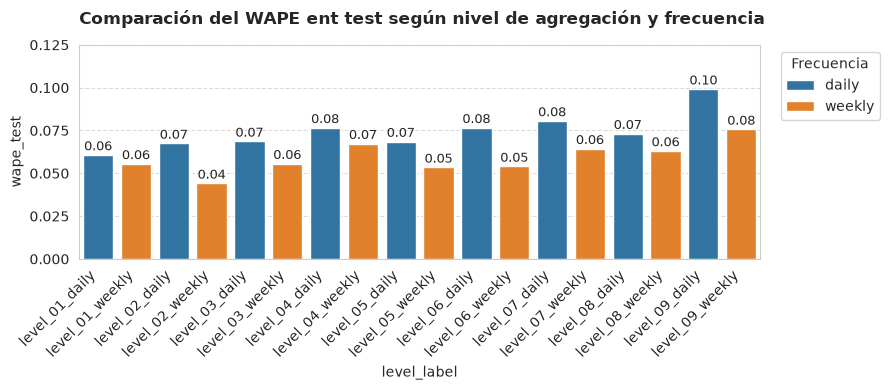

In [6]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level_label",
    y="wape_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 0.13, 0.025))

plt.title("Comparación del WAPE ent test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Frecuencia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

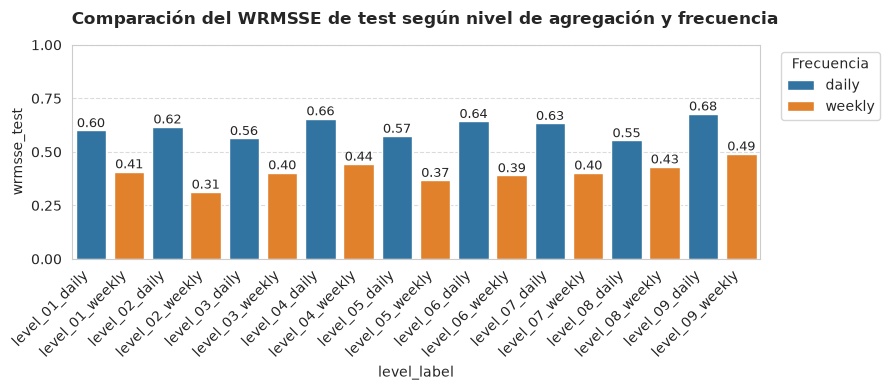

In [7]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level_label",
    y="wrmsse_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 1.25, 0.25))

plt.title("Comparación del WRMSSE de test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Frecuencia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
df_metrics_long = df_comparative.melt(
    id_vars=["level_label", "grainly"],
    value_vars=["wape_test", "wape_valid", "wrmsse_test", "wrmsse_valid"],
    var_name="metric_conjunto",
    value_name="valor",
)

df_metrics_long[["metric", "conjunto"]] = df_metrics_long["metric_conjunto"].str.split("_", expand=True)

df_metrics_long.drop(columns=["metric_conjunto"], inplace=True)

df_metrics_long = df_metrics_long.set_index('level_label')

df_metrics_long.head()

,grainly,valor,metric,conjunto
level_label,,,,
level_01_daily,daily,0.0607,wape,test
level_01_weekly,weekly,0.0555,wape,test
level_02_daily,daily,0.0674,wape,test
level_02_weekly,weekly,0.0441,wape,test
level_03_daily,daily,0.0686,wape,test


In [9]:
df_metrics_long['metric'].unique()

<ArrowStringArray>
['wape', 'wrmsse']
Length: 2, dtype: str

In [10]:
df_metrics_long.query("metric == 'wrmsse'")

,grainly,valor,metric,conjunto
level_label,,,,
level_01_daily,daily,0.6005,wrmsse,test
level_01_weekly,weekly,0.4083,wrmsse,test
level_02_daily,daily,0.6177,wrmsse,test
level_02_weekly,weekly,0.3133,wrmsse,test
level_03_daily,daily,0.5635,wrmsse,test
level_03_weekly,weekly,0.4036,wrmsse,test
level_04_daily,daily,0.6558,wrmsse,test
level_04_weekly,weekly,0.4441,wrmsse,test
level_05_daily,daily,0.5741,wrmsse,test


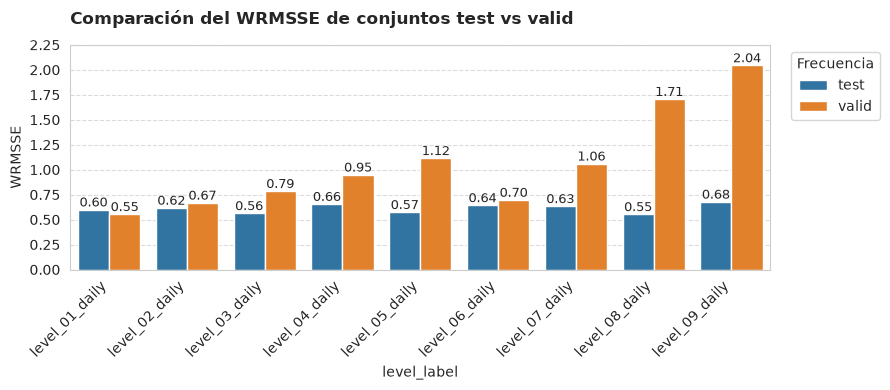

In [11]:
df_wrmsse_daily = df_metrics_long.query("metric == 'wrmsse' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wrmsse_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 2.5, 0.25))

plt.ylabel("WRMSSE")

plt.title("Comparación del WRMSSE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Frecuencia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

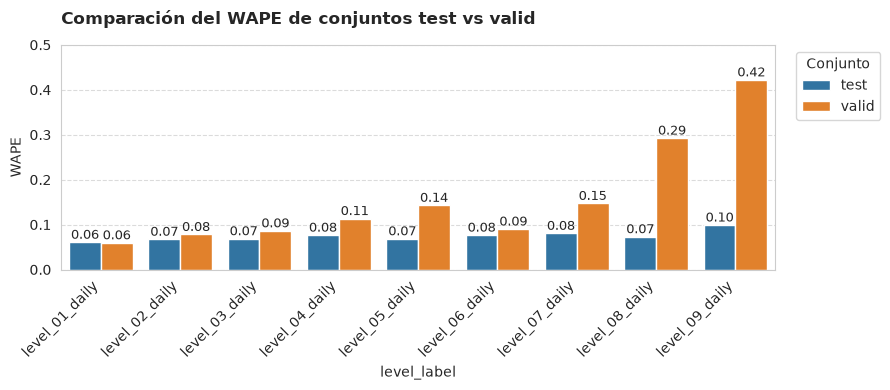

In [12]:
df_wape_daily = df_metrics_long.query("metric == 'wape' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wape_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.ylabel("WAPE")

plt.yticks(np.arange(0, .6, 0.1))

plt.title("Comparación del WAPE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Conjunto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 1. Carga de artifacts, reconstrucción de test y predicciones

## 1.1 Carga

In [13]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]

def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
        "train": train,
        "dims_available": dims_available,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_label"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


2026-09-15 20:46:12.452 | INFO     | __main__:<module>:33 - Artifacts encontrados: ['level_01_daily_total_sales_artifact.pkl', 'level_01_weekly_total_sales_artifact.pkl', 'level_02_daily_state_sales_artifact.pkl', 'level_02_weekly_state_sales_artifact.pkl', 'level_03_daily_cat_sales_artifact.pkl', 'level_03_weekly_cat_sales_artifact.pkl', 'level_04_daily_dept_sales_artifact.pkl', 'level_04_weekly_dept_sales_artifact.pkl', 'level_05_daily_state_cat_sales_artifact.pkl', 'level_05_weekly_state_cat_sales_artifact.pkl', 'level_06_daily_store_sales_artifact.pkl', 'level_06_weekly_store_sales_artifact.pkl', 'level_07_daily_state_dept_sales_artifact.pkl', 'level_07_weekly_state_dept_sales_artifact.pkl', 'level_08_daily_store_cat_sales_artifact.pkl', 'level_08_weekly_store_cat_sales_artifact.pkl', 'level_09_daily_store_dept_sales_artifact.pkl', 'level_09_weekly_store_dept_sales_artifact.pkl']


2026-09-15 20:46:13.532 | INFO     | src.data.dataset:load_data:58 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)


2026-09-15 20:46:13.547 | INFO     | src.data.temporal_split:log_summary:41 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 1,549 rows)


2026-09-15 20:46:13.549 | INFO     | src.data.temporal_split:log_summary:42 - Valid : 2015-04-27 to 2016-04-24 (364 days, 364 rows)


2026-09-15 20:46:13.550 | INFO     | src.data.temporal_split:log_summary:43 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)


...

2026-09-15 20:46:32.185 | INFO     | src.data.temporal_split:log_summary:41 - Train : 2011-01-29 to 2015-04-20 (1,549 days, 15,540 rows)


2026-09-15 20:46:32.186 | INFO     | src.data.temporal_split:log_summary:42 - Valid : 2015-04-27 to 2016-04-18 (364 days, 3,640 rows)


2026-09-15 20:46:32.188 | INFO     | src.data.temporal_split:log_summary:43 - Test  : 2016-04-25 to 2016-05-16 (22 days, 280 rows)


2026-09-15 20:46:32.431 | INFO     | src.data.dataset:split_data:119 - Features: 25 (2 categóricas)


2026-09-15 20:46:32.579 | INFO     | __main__:<module>:39 - level_09_weekly_store_dept | 70 series | modelo=FittedModel | WAPE test=7.56% | WRMSSE test=0.492


## 2. Resumen de cada modelo en su propio nivel nativo

In [14]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_label": res["level_label"],
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_label")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


,level,n_series,modelo,wape,wrmsse,bias,rmse
level_label,,,,,,,
level_01_daily,level_01_daily_total,1,FittedModel,6.07%,0.601,-5.95%,"3,435.9"
level_01_weekly,level_01_weekly_total,1,FittedModel,5.55%,0.408,-5.55%,"19,575.3"
level_02_daily,level_02_daily_state,3,FittedModel,6.74%,0.618,-6.19%,"1,314.6"
level_02_weekly,level_02_weekly_state,3,FittedModel,4.41%,0.313,-3.95%,"5,274.9"
level_03_daily,level_03_daily_cat,3,FittedModel,6.86%,0.564,-6.45%,"1,705.2"
level_03_weekly,level_03_weekly_cat,3,FittedModel,5.56%,0.404,-3.53%,"9,105.9"
level_04_daily,level_04_daily_dept,7,FittedModel,7.65%,0.656,-6.16%,839.9
level_04_weekly,level_04_weekly_dept,7,FittedModel,6.73%,0.444,-4.96%,"4,532.1"
level_05_daily,level_05_daily_state_cat,9,FittedModel,6.85%,0.574,-5.34%,582.1


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
diaria total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. También se arma una combinación simple: el
promedio de las 4 predicciones totales, como primer paso hacia una reconciliación
jerárquica más formal (bottom-up ya está acá; top-down por proporciones históricas
o MinT/optimal reconciliation -- p.ej. con `hierarchicalforecast` -- quedan como
extensión natural).

In [15]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


def to_weekly(agg: pd.DataFrame) -> pd.DataFrame:
    """Reagrega una serie diaria a semanal (lunes-domingo, fecha = lunes de esa
    semana, igual que el date_trunc('week', ...) usado al construir los datasets
    weekly -- ver src/data/base_query.py) para que sea comparable con L1, que
    solo tiene artifact weekly."""
    week_start = agg.index - pd.to_timedelta(agg.index.dayofweek, unit="D")
    return agg.groupby(week_start).sum()


# Solo se agregan al total los niveles que particionan por completo la serie total
# (item/item_store, 10-12, están filtrados a un subconjunto dept/store y no sumarían al total real).
VALID_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# LEVELS está keyeado por level_label ("level_04_daily", "level_04_weekly", ...),
# no por level_id: varios niveles (3, 5-9) tienen artifacts en ambos grains -- nos
# quedamos con el nativo daily de cada nivel (más fino) y sólo caemos a weekly
# cuando no hay daily entrenado (caso de L1 hoy).
GRAIN_PRIORITY = {"daily": 0, "weekly": 1}

def grain_of(res: dict) -> str:
    return res["level_label"].rsplit("_", 1)[-1]

levels_by_id: dict[int, dict] = {}
for res in LEVELS.values():
    level_id = res["level_id"]
    current = levels_by_id.get(level_id)
    if current is None or GRAIN_PRIORITY[grain_of(res)] < GRAIN_PRIORITY[grain_of(current)]:
        levels_by_id[level_id] = res

# L1 solo existe en weekly: todo se reagrega a semanal (lunes de cada semana)
# para poder comparar contra L1 en la misma base -- sumar los diarios a nivel de
# semana no pierde nada (es la misma cuenta agregada distinto), pero unirlos sin
# reagregar sí: las fechas diarias y semanales no calzan al pegar columnas por
# índice (cada fecha semanal solo matchea el día puntual, no la semana entera).
total_aggs = {
    level_id: to_weekly(aggregate_to_total(res["df_pred"])) if grain_of(res) == "daily"
    else aggregate_to_total(res["df_pred"])
    for level_id, res in levels_by_id.items()
    if level_id in VALID_LEVELS
}

df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
for level_id, agg in sorted(total_aggs.items()):
    df_total[f"L{level_id}"] = agg["y_pred"]

# combinación naive: promedio de las predicciones de todos los niveles disponibles
pred_cols = [c for c in df_total.columns if c != "actual"]
#df_total["Promedio de niveles"] = df_total[pred_cols].mean(axis=1)

df_total.round(0).head()

,actual,L1,L2,L3,L4,L5,L6,L7,L8,L9
date,,,,,,,,,,
2016-04-25,"289,814.0000","280,923.0000","279,157.0000","280,339.0000","283,668.0000","282,057.0000","278,886.0000","283,755.0000","283,554.0000","283,902.0000"
2016-05-02,"311,512.0000","295,087.0000","294,782.0000","294,894.0000","297,023.0000","299,349.0000","297,018.0000","302,252.0000","302,423.0000","303,342.0000"
2016-05-09,"326,832.0000","300,277.0000","297,683.0000","295,569.0000","293,792.0000","299,030.0000","297,876.0000","298,806.0000","305,336.0000","300,217.0000"
2016-05-16,"303,606.0000","282,171.0000","283,858.0000","281,563.0000","281,429.0000","285,503.0000","281,813.0000","284,786.0000","292,035.0000","286,219.0000"


In [16]:
# Escala WRMSSE del total: MSE del naive de 1 día in-sample sobre el train del
# nivel L1 (la serie total ya es una sola serie -- no hay ponderación entre grupos).
train_total = levels_by_id[1]["train"][["date", "sales"]].copy()
train_total["series_id"] = "TOTAL"
scale_total = compute_naive_scales(train_total, group_col="series_id", target_col="sales")["TOTAL"]

rows = []
for col in [c for c in df_total.columns if c != "actual"]:
    y_true, y_pred = df_total["actual"], df_total[col]
    rows.append({
        "enfoque": col,
        "wape": wape(y_true, y_pred),
        "bias": bias(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "wrmsse": rmse(y_true, y_pred) / np.sqrt(scale_total),
    })

df_total_metrics = pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)
df_total_metrics

,enfoque,wape,bias,rmse,wrmsse
0,L8,0.0393,-0.0393,"13,395.5550",2.3413
1,L9,0.0472,-0.0472,"16,676.0805",2.9147
2,L7,0.0505,-0.0505,"17,763.0808",3.1046
3,L5,0.0534,-0.0534,"18,088.5283",3.1615
4,L1,0.0595,-0.0595,"19,451.5922",3.3998
5,L4,0.0616,-0.0616,"21,396.0590",3.7396
6,L6,0.0618,-0.0618,"20,266.2404",3.5422
7,L2,0.0619,-0.0619,"20,205.8918",3.5316
8,L3,0.0645,-0.0645,"21,384.5889",3.7376


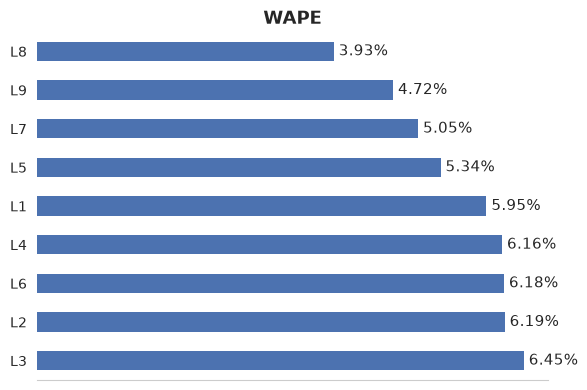

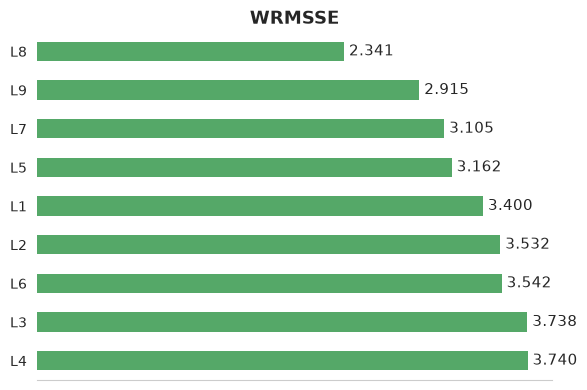

In [17]:
import matplotlib.pyplot as plt

df_plot = df_total_metrics.set_index("enfoque")

metrics = {"wape": ("WAPE", "%"), "wrmsse": ("WRMSSE", "num")}
colors = {"wape": "#4C72B0", "bias": "#DD8452", "wrmsse": "#55A868"}

for metric, (title, fmt_type) in metrics.items():
    sort_type = False if metric in ["wape", "wrmsse"] else False
    data = df_plot[metric].sort_values(ascending=sort_type)

    fig, ax = plt.subplots(figsize=(6, 4))
    data.plot(kind="barh", ax=ax, color=colors[metric], edgecolor="none")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xticks([])

    for i, v in enumerate(data):
        label = f"{v:.2%}" if fmt_type == "%" else f"{v:.3f}"
        ax.text(v, i, f" {label}", va="center", fontsize=11)

    plt.tight_layout()
    plt.grid(False)
    plt.show()

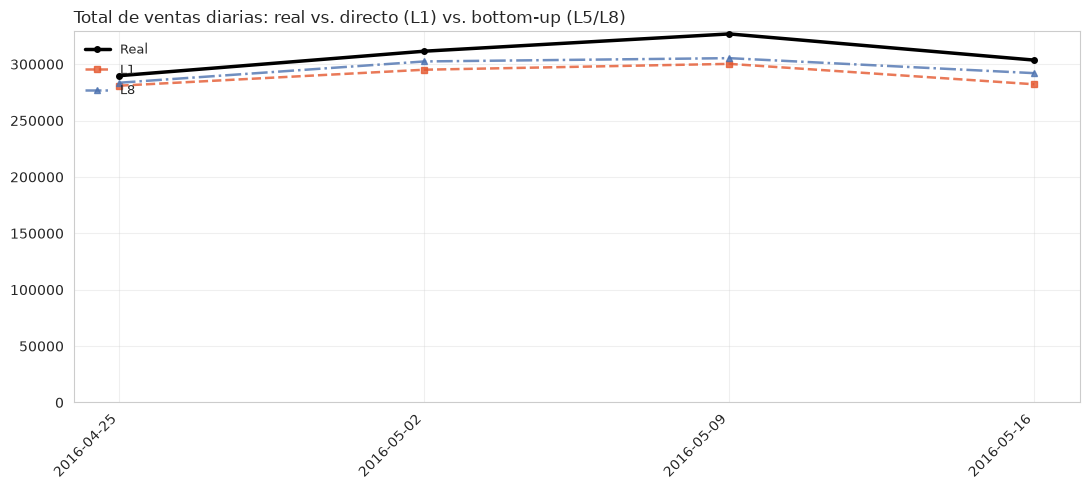

In [18]:
df_plot = df_total[['actual', 'L1', 'L8']].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_plot.index, df_plot["actual"], label="Real", color="black",
        linewidth=2.5, marker="o", markersize=4, zorder=3)

styles = [
    {"color": "#E4572E", "linestyle": "--", "marker": "s"},
    {"color": "#4C72B0", "linestyle": "-.", "marker": "^"},
    {"color": "#55A868", "linestyle": ":", "marker": "D"},
]

for col, style in zip([c for c in df_plot.columns if c != "actual"], styles):
    ax.plot(df_plot.index, df_plot[col], label=col, alpha=0.8,
            linewidth=1.8, markersize=4, zorder=2, **style)

ax.set_title("Total de ventas diarias: real vs. directo (L1) vs. bottom-up (L5/L8)", loc="left")
ax.set_xlabel("")
ax.set_xticks(df_plot.index)
ax.legend(loc="upper left", fontsize=9, frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.ylim(0)
plt.show()

## Conclusiones rápidas

- Revisar `df_total_metrics`: si "Promedio de niveles" queda por debajo del mejor
  enfoque individual, hay señal de que combinar información de distintos niveles
  de agregación reduce error -- la motivación estándar detrás de la reconciliación
  jerárquica (bottom-up, top-down, MinT).
- `df_dept_compare` / `df_store_compare` (columna `gana_bottomup`) muestran, serie
  por serie, si conviene más el modelo especializado en ese nivel o la suma desde
  el nivel más fino -- normalmente depende de cuánta señal específica del grupo
  (dept/store) exista vs. cuánta información se gana de tener series individuales
  más finas para el modelo de L9.
- Extensión natural: formalizar esto con reconciliación óptima (p.ej.
  `hierarchicalforecast` de Nixtla, que ya cubre bottom-up/top-down/MinT sobre esta
  misma estructura de niveles).
